### Imports e iniciando cessão com o S3

In [1]:
import pandas as pd 
import boto3 

from dotenv import load_dotenv
from datetime import datetime
from src.data.utils import *

load_dotenv()

True

In [2]:
session = iniciar_cessao_aws()
s3 = session.client("s3")

BUCKET = os.getenv("BUCKET_NAME")


In [3]:
import os
from pathlib import Path
import dotenv

pasta_atual = Path().resolve()
caminho_env = pasta_atual.parent / '.env'

print("1. Onde o Python está procurando o .env?")
print(caminho_env)
print("------------------")
print("2. O arquivo .env realmente existe nesse exato local?")
print(caminho_env.exists())
print("------------------")

dotenv.load_dotenv(caminho_env)
print("3. As chaves foram encontradas dentro do arquivo?")
print("BUCKET:", os.getenv("BUCKET_NAME"))
print("ACCESS KEY existe?", os.getenv("AWS_ACCESS_KEY_ID") is not None)
print("SECRET KEY existe?", os.getenv("AWS_SECRET_ACCESS_KEY") is not None)

1. Onde o Python está procurando o .env?
C:\Users\jack_\OneDrive\Área de Trabalho\TECH CHALLENGE 3\fiap_tech_challenge_03\.env
------------------
2. O arquivo .env realmente existe nesse exato local?
True
------------------
3. As chaves foram encontradas dentro do arquivo?
BUCKET: postech-challenge-datascience-003
ACCESS KEY existe? True
SECRET KEY existe? True


In [4]:
BUCKET
print(BUCKET)

postech-challenge-datascience-003


### Lendo arquivos do S3

In [5]:
tabelas = ['RESULTADOS_METAS_MUNICIPIO','RESULTADOS_METAS','RESULTADOS_METAS_MUNICIPIO','TS_ALUNO','TS_ESTADO','TS_ITEM','TS_MUNICIPIO','Fato_Alfabetizacao_Meta' ] 
pastas = ['dimensao','historico','fato/ano=2026'] 


# resultado_metas = carregar_parquet_s3(
#     s3_client=s3,
#     bucket=BUCKET,
#     ano= pastas[1],
#     nome_tabela=tabelas[1],
#     camada="gold"
# )

# resultado_metas_muni = carregar_parquet_s3(
#     s3_client=s3,
#     bucket=BUCKET,
#     ano= pastas[1],
#     nome_tabela=tabelas[2],
#     camada="gold"
# )

df_meta = ler_fato_s3(
    s3_client=s3,
    bucket=BUCKET,
    ano= pastas[2],
    nome_tabela=tabelas[7],
    camada="gold"
)

Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/Fato_Alfabetizacao_Meta.parquet


In [6]:
print(f' qtd observações metas : {df_meta.shape[0]}')

 qtd observações metas : 11589070


In [7]:
display(df_meta.isna().sum()) 

NU_ANO_AVALIACAO                      0
CO_UF                                 0
CO_MUNICIPIO                          0
ID_ESCOLA                             0
TP_DEPENDENCIA                        0
DESC_SERIE                            0
QT_ALUNOS                             0
QT_PRESENTES_LP                       0
QT_PREENCHIMENTO_LP                   0
QT_ALFABETIZADOS                      0
VL_MEAN_PROFICIENCIA_LP           71227
VL_MIN_PROFICIENCIA_LP            71227
VL_MAX_PROFICIENCIA_LP            71227
VL_MED_PROFICIENCIA_LP            71227
VL_STD_PROFICIENCIA_LP            73489
VL_VAR_PROFICIENCIA_LP            73489
ABSTENCAO_LP                          0
P25_PROFICIENCIA_LP                   0
P75_PROFICIENCIA_LP                   0
P90_PROFICIENCIA_LP                   0
AMP_PROFICIENCIA_LP               71227
RANKING_MUNICIPIO                 71227
RANKING_ESTADO                    71227
RANKING_BRASIL                    71227
ID_TIPO_REDE                       9137


In [8]:
df_meta.describe().T

,count,mean,std,min,25%,50%,75%,max
NU_ANO_AVALIACAO,11589070.0,2023.659757,0.829162,2023.0,2023.0,2023.0,2024.0,2025.0
CO_UF,11589070.0,30.922194,10.415535,11.0,23.0,31.0,41.0,53.0
CO_MUNICIPIO,11589070.0,3102826.058989,1043456.893462,1100015.0,2310506.0,3104007.0,4113700.0,5300108.0
ID_ESCOLA,11589070.0,60020350.070531,12898.67641,60000001.0,60009179.0,60018530.0,60033628.0,60043644.0
TP_DEPENDENCIA,11589070.0,2.904794,0.293514,2.0,3.0,3.0,3.0,4.0
QT_ALUNOS,11589070.0,48.351323,36.682285,2.0,21.0,39.0,64.0,441.0
QT_PRESENTES_LP,11589070.0,41.732257,31.492053,0.0,19.0,33.0,55.0,388.0
QT_PREENCHIMENTO_LP,11589070.0,41.704662,31.468447,0.0,19.0,33.0,55.0,388.0
QT_ALFABETIZADOS,11589070.0,26.145112,22.181748,0.0,11.0,20.0,35.0,311.0
VL_MEAN_PROFICIENCIA_LP,11517843.0,751.249453,27.967749,601.063244,733.540705,749.34,765.750833,885.02327


In [25]:
df_meta[['QT_ALUNOS','QT_ALFABETIZADOS']]

,QT_ALUNOS,QT_ALFABETIZADOS
0,16,0
1,16,0
2,16,0
3,16,0
4,16,0
...,...,...
11589065,269,159
11589066,269,159
11589067,269,159
11589068,269,159


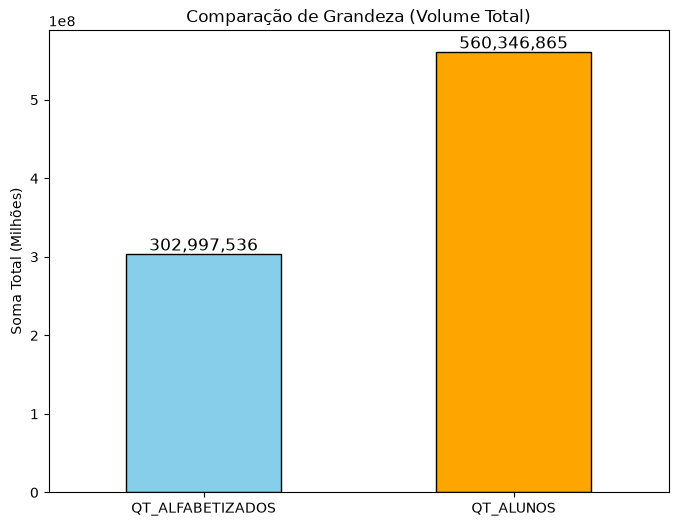

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

totais = df_meta[['QT_ALFABETIZADOS', 'QT_ALUNOS']].sum()
totais.plot.bar(color=['skyblue', 'orange'], edgecolor='black')

plt.title('Comparação de Grandeza (Volume Total)')
plt.ylabel('Soma Total (Milhões)')
plt.xticks(rotation=0) # Deixa o texto do eixo X deitado (horizontal)


for i, valor in enumerate(totais):
    plt.text(i, valor, f'{valor:,.0f}', ha='center', va='bottom', fontsize=12)

plt.show()


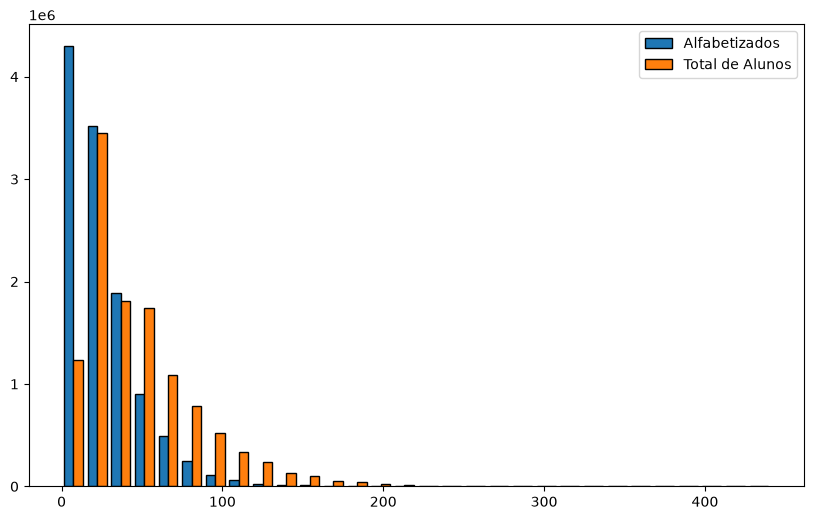

In [ ]:
# Alternativa puramente com Matplotlib
plt.figure(figsize=(10, 6))

plt.hist(
    [df_meta['QT_ALFABETIZADOS'], df_meta['QT_ALUNOS']], 
    bins=30, 
    label=['Alfabetizados', 'Total de Alunos'],
    edgecolor='black'
)

plt.legend()
plt.show()


In [ ]:
tabelas = ['RESULTADOS_METAS_MUNICIPIO','RESULTADOS_METAS_MUNICIPIO','RESULTADOS_METAS','TS_ALUNO','TS_ESTADO','TS_ITEM','TS_MUNICIPIO' ] 
pastas = ['dimensao','historico','fato'] 


df = carregar_parquet_s3(
    s3_client=s3,
    bucket=BUCKET,
    ano= pastas[0],
    nome_tabela=tabelas[0],
    camada="gold"
)


Lendo: s3://postech-challenge-datascience-003/gold/ano=dimensao/dados/RESULTADOS_METAS_MUNICIPIO.parquet
